### AI LAB ASSIGNMENT 11
### NAME - UTKARSH YADAV
### ROLL - 23053172
### SEC - CSE 33

### TOPIC - SOLVING THE WATER-JUGS PROBLEM USING ADVERSARIAL SEARCH

In [11]:
# Jug capacities and target
A = 4
B = 3
T = 2

initial_state = (0, 0)

print("Jug A Capacity:", A)
print("Jug B Capacity:", B)
print("Target:", T)
print("Initial State:", initial_state)

Jug A Capacity: 4
Jug B Capacity: 3
Target: 2
Initial State: (0, 0)


In [12]:
def get_moves(state):
    x, y = state
    moves = []

    # Fill
    moves.append((A, y))
    moves.append((x, B))

    # Empty
    moves.append((0, y))
    moves.append((x, 0))

    # Pour A -> B
    transfer = min(x, B - y)
    moves.append((x - transfer, y + transfer))

    # Pour B -> A
    transfer = min(y, A - x)
    moves.append((x + transfer, y - transfer))

    return list(set(moves))

# Testing function get_moves
state = (0, 0)
print("Possible moves from", state, ":", get_moves(state))

Possible moves from (0, 0) : [(0, 0), (4, 0), (0, 3)]


In [13]:
def is_terminal(state):
    x, y = state
    return x == T or y == T

# Testing function is_terminal
print(is_terminal((2, 0)))  # True
print(is_terminal((1, 3)))  # False

True
False


In [14]:
def utility(state, depth, is_max):
    x, y = state
    if x == T or y == T:
        return 10 - depth if is_max else depth - 10
    return 0

# Testing function utility
print(utility((2,0), 2, True))
print(utility((2,0), 2, False))

8
-8


In [15]:
def minimax(state, depth, is_max, visited):
    if state in visited:
        return 0

    if is_terminal(state):
        return utility(state, depth, is_max)

    visited.add(state)
    moves = get_moves(state)

    if is_max:
        best = float('-inf')
        for move in moves:
            val = minimax(move, depth + 1, False, visited.copy())
            best = max(best, val)
        return best
    else:
        best = float('inf')
        for move in moves:
            val = minimax(move, depth + 1, True, visited.copy())
            best = min(best, val)
        return best

# Testing function minimax
print("Minimax value from initial state:", minimax((0,0), 0, True, set()))

Minimax value from initial state: 0


In [16]:
def alphabeta(state, depth, alpha, beta, is_max, visited):
    if state in visited:
        return 0

    if is_terminal(state):
        return utility(state, depth, is_max)

    visited.add(state)
    moves = get_moves(state)

    if is_max:
        value = float('-inf')
        for move in moves:
            value = max(value, alphabeta(move, depth + 1, alpha, beta, False, visited.copy()))
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        return value
    else:
        value = float('inf')
        for move in moves:
            value = min(value, alphabeta(move, depth + 1, alpha, beta, True, visited.copy()))
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value

# Testing function alphabeta
print("Alpha-Beta value:", alphabeta((0,0), 0, float('-inf'), float('inf'), True, set()))

Alpha-Beta value: 0


In [17]:
def best_move(state, use_alpha_beta=True):
    moves = get_moves(state)
    best_val = float('-inf')
    best_state = None

    for move in moves:
        if use_alpha_beta:
            val = alphabeta(move, 0, float('-inf'), float('inf'), False, set())
        else:
            val = minimax(move, 0, False, set())

        print(f"Move {move} → Value {val}")

        if val > best_val:
            best_val = val
            best_state = move

    return best_state

# Testing function best_move
print("Best move from (0,0):", best_move((0,0)))

Move (0, 0) → Value 0
Move (4, 0) → Value 0
Move (0, 3) → Value 0
Best move from (0,0): (0, 0)


In [19]:
def play_game():
    state = (0, 0)

    while True:
        print("\nCurrent State:", state)

        # Human turn
        moves = get_moves(state)
        print("Available moves:")
        for i, m in enumerate(moves):
            print(i, ":", m)

        choice = int(input("Enter your move index: "))
        state = moves[choice]

        if is_terminal(state):
            print("🎉 You Win!", state)
            break

        # AI turn
        print("\nAI thinking...")
        state = best_move(state)

        print("AI chose:", state)

        if is_terminal(state):
            print("🤖 AI Wins!", state)
            break

In [20]:
import time
import matplotlib.pyplot as plt

def measure_time():
    state = (0, 0)

    start = time.time()
    minimax(state, 0, True, set())
    t1 = time.time() - start

    start = time.time()
    alphabeta(state, 0, float('-inf'), float('inf'), True, set())
    t2 = time.time() - start

    return t1, t2


t1, t2 = measure_time()

print("Minimax Time:", t1)
print("Alpha-Beta Time:", t2)

Minimax Time: 0.0003235340118408203
Alpha-Beta Time: 1.7642974853515625e-05


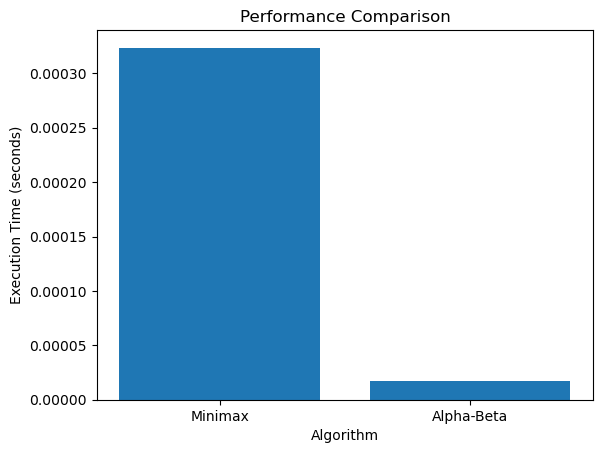

In [21]:
# Visualisation

labels = ['Minimax', 'Alpha-Beta']
times = [t1, t2]

plt.figure()
plt.bar(labels, times)
plt.xlabel("Algorithm")
plt.ylabel("Execution Time (seconds)")
plt.title("Performance Comparison")
plt.show()

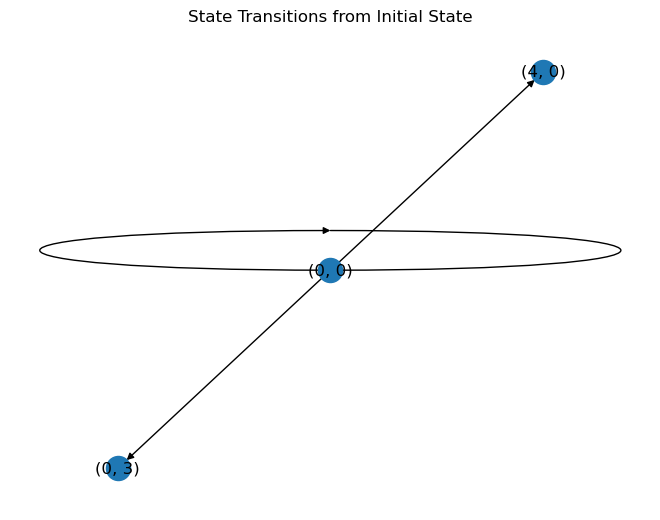

In [22]:
import networkx as nx

G = nx.DiGraph()

state = (0, 0)
moves = get_moves(state)

for m in moves:
    G.add_edge(state, m)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.title("State Transitions from Initial State")
plt.show()